In [16]:
# Import libraries required for model comparison

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
# Load the prepared Walmart training dataset

train_df = pd.read_csv(
    r"E:\Retail_Demand_Forecasting\Data\train_EDA.csv"
)

print("Dataset shape:", train_df.shape)
print(train_df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_10344\907423942.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(


Dataset shape: (421577, 20)
   Store  Dept  Weekly_Sales IsHoliday  Temperature  Fuel_Price  MarkDown1  \
0    1.0     1      24924.50     False        42.31       2.572        0.0   
1    1.0     1      46039.49      True        38.51       2.548        0.0   
2    1.0     1      41595.55     False        39.93       2.514        0.0   
3    1.0     1      19403.54     False        46.63       2.561        0.0   
4    1.0     1      21827.90     False        46.50       2.625        0.0   

   MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  \
0        0.0        0.0        0.0        0.0  211.096358         8.106   
1        0.0        0.0        0.0        0.0  211.242170         8.106   
2        0.0        0.0        0.0        0.0  211.289143         8.106   
3        0.0        0.0        0.0        0.0  211.319643         8.106   
4        0.0        0.0        0.0        0.0  211.350143         8.106   

       Size    Year  Month  Week  Quarter  Type_B  T

In [18]:
# Separate features and target

X = train_df.drop("Weekly_Sales", axis=1)
y = train_df["Weekly_Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (421577, 19)
Target shape: (421577,)


In [19]:
# Split data based on Year

X_train = X[X["Year"] < 2012]
y_train = y[X["Year"] < 2012]

X_val = X[X["Year"] == 2012]
y_val = y[X["Year"] == 2012]

print("Training features:", X_train.shape)
print("Training target:", y_train.shape)
print("Validation features:", X_val.shape)
print("Validation target:", y_val.shape)

Training features: (294132, 19)
Training target: (294132,)
Validation features: (127438, 19)
Validation target: (127438,)


In [20]:
# Import the regression models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [21]:
# Create the three regression models

linear_model = LinearRegression()

dt_model = DecisionTreeRegressor(
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Check missing values in the training features

missing_values = X_train.isnull().sum()

print(missing_values[missing_values > 0])

Store          7
Temperature    7
Fuel_Price     7
Size           7
dtype: int64


In [ ]:
# Find the rows containing missing values

missing_rows = X_train[X_train.isnull().any(axis=1)]

print("Number of rows with missing values:", len(missing_rows))
print(missing_rows)

Number of rows with missing values: 7
        Store  Dept IsHoliday  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
131664    NaN    27     False          NaN         NaN        0.0        0.0   
232225    NaN    40     False          NaN         NaN        0.0        0.0   
265666    NaN    90     False          NaN         NaN        0.0        0.0   
299491    NaN    44     False          NaN         NaN        0.0        0.0   
334692    NaN    30     False          NaN         NaN        0.0        0.0   
367173    NaN    52     False          NaN         NaN        0.0        0.0   
401446    NaN    42     False          NaN         NaN        0.0        0.0   

        MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  Size  \
131664        0.0        0.0        0.0  182.616521         8.743   NaN   
232225        0.0        0.0        0.0  136.054032         8.358   NaN   
265666        0.0        0.0        0.0  135.668225         8.237   NaN   
299491        0.0    

In [ ]:
# Check the target values for the rows with missing features

missing_target = y_train.loc[missing_rows.index]

print(missing_target)

131664     2536.45
232225    45200.91
265666    96232.14
299491     2318.31
334692     5814.74
367173     1622.26
401446      162.48
Name: Weekly_Sales, dtype: float64


In [ ]:
# Remove the 7 rows with missing predictor values

X_train_clean = X_train.dropna()
y_train_clean = y_train.loc[X_train_clean.index]

print("Clean training features:", X_train_clean.shape)
print("Clean training target:", y_train_clean.shape)

Clean training features: (294125, 19)
Clean training target: (294125,)


In [23]:
# Train all three regression models

linear_model.fit(X_train_clean, y_train_clean)
dt_model.fit(X_train_clean, y_train_clean)
rf_model.fit(X_train_clean, y_train_clean)

print("All three models trained successfully.")

All three models trained successfully.


In [24]:
# Generate predictions on the validation set

y_pred_linear = linear_model.predict(X_val)
y_pred_dt = dt_model.predict(X_val)
y_pred_rf = rf_model.predict(X_val)

print("Predictions generated successfully.")

Predictions generated successfully.


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE
mae_linear = mean_absolute_error(y_val, y_pred_linear)
mae_dt = mean_absolute_error(y_val, y_pred_dt)
mae_rf = mean_absolute_error(y_val, y_pred_rf)

# Calculate RMSE
rmse_linear = np.sqrt(mean_squared_error(y_val, y_pred_linear))
rmse_dt = np.sqrt(mean_squared_error(y_val, y_pred_dt))
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print("Linear Regression")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)

print("\nDecision Tree")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)

print("\nRandom Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Linear Regression
MAE: 14157.095291054235
RMSE: 21094.529421797615

Decision Tree
MAE: 2979.0813572089955
RMSE: 6706.3226005798615

Random Forest
MAE: 2628.63588325244
RMSE: 5390.733921512903


In [26]:
# Create a comparison table for all three models

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_dt,
        rmse_rf
    ]
})

print(comparison_df)

               Model           MAE          RMSE
0  Linear Regression  14157.095291  21094.529422
1      Decision Tree   2979.081357   6706.322601
2      Random Forest   2628.635883   5390.733922


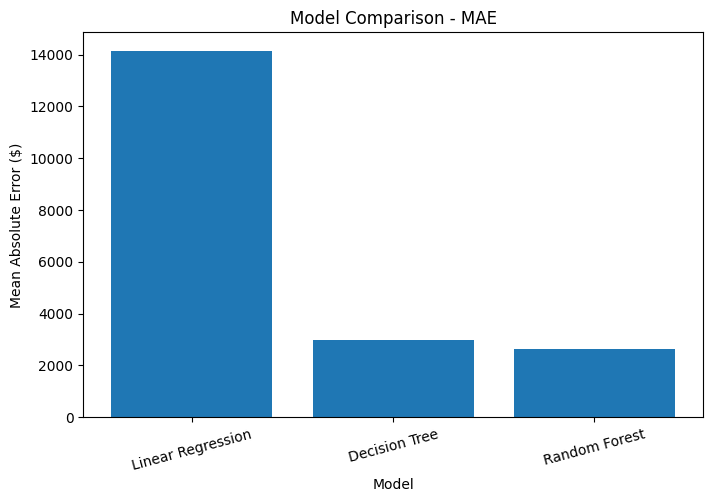

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Model"], comparison_df["MAE"])

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error ($)")
plt.xticks(rotation=15)

plt.show()

### Model Comparison Interpretation

Three regression models were evaluated using the same Walmart training and validation dataset.

- Linear Regression produced an MAE of $14,157.10 and RMSE of $21,094.53.
- Decision Tree Regressor produced an MAE of $2,979.08 and RMSE of $6,706.32.
- Random Forest Regressor produced an MAE of $2,628.64 and RMSE of $5,390.73.

The results show that the tree-based models produced substantially lower prediction errors than Linear Regression on the validation data. The Random Forest model had the lowest MAE and RMSE among the three models tested.

In [28]:
from sklearn.metrics import r2_score

# Calculate R²
r2_linear = r2_score(y_val, y_pred_linear)
r2_dt = r2_score(y_val, y_pred_dt)
r2_rf = r2_score(y_val, y_pred_rf)

print("Linear Regression R²:", r2_linear)
print("Decision Tree R²:", r2_dt)
print("Random Forest R²:", r2_rf)

Linear Regression R²: 0.09060719090429514
Decision Tree R²: 0.908086201514321
Random Forest R²: 0.9406107794941642


In [30]:
# Create the final model comparison table

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_dt,
        rmse_rf
    ],
    "R²": [
        r2_linear,
        r2_dt,
        r2_rf
    ]
})

print(comparison_df)

               Model           MAE          RMSE        R²
0  Linear Regression  14157.095291  21094.529422  0.090607
1      Decision Tree   2979.081357   6706.322601  0.908086
2      Random Forest   2628.635883   5390.733922  0.940611


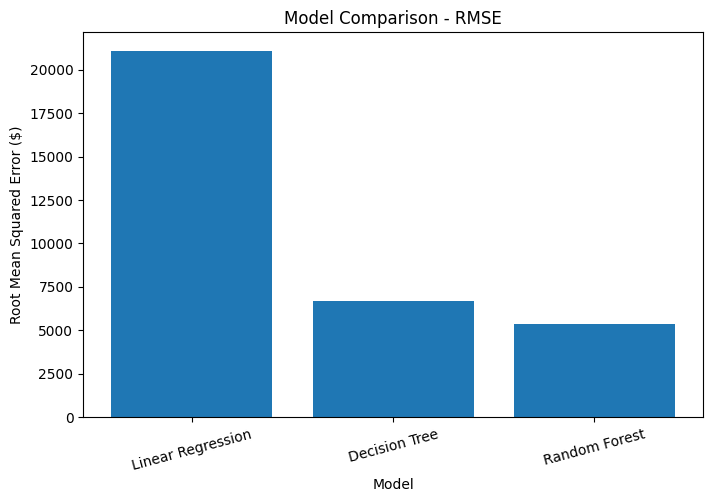

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Model"], comparison_df["RMSE"])

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error ($)")
plt.xticks(rotation=15)

plt.show()

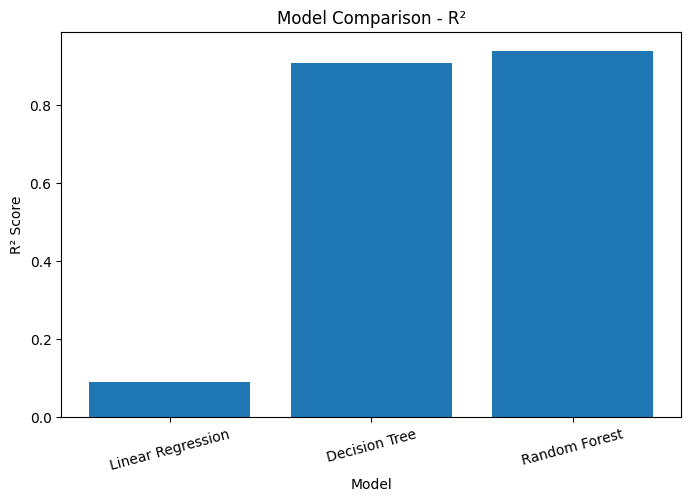

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Model"], comparison_df["R²"])

plt.title("Model Comparison - R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

### Model Comparison
Compared Linear Regression, Decision Tree, and Random Forest using the same features and time-based validation split.
Random Forest achieved the lowest MAE ($2,628.64) and RMSE ($5,390.73), with an R² of 0.9406.
The results show that the tree-based models captured Walmart weekly sales patterns better than Linear Regression.
Random Forest provided the strongest validation performance in this comparison.